In [115]:
# -*- coding: utf-8 -*-
"""

@author: profa
"""
%pip install "numpy==1.26.4" --no-binary "numpy==1.26.4"
%pip install scikit-learn
import numpy as np
from tensorflow.keras.layers import Activation
 #https://www.tensorflow.org/api_docs/python/tf/keras/Input

import nltk
import pandas as pd
import sklearn
import re  
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import tensorflow.keras
#from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras import layers

 

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
## For Stemming
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
import os

from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import string

from bs4 import BeautifulSoup
from collections import Counter

from nltk.corpus import stopwords
#nltk.download('stopwords')
from nltk.tokenize import word_tokenize

 


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [116]:

## These settings show/print dfs in diff ways
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 50)
#pd.options.display.max_seq_items = None
#pd.pandas.set_option('display.max_columns', None)
pd.options.display.max_colwidth = 50



In [117]:

## Sentiment analysis
%pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
analyzer.polarity_scores("That was awesome!")
sentDF = pd.read_csv("../combinedtextdata.csv")
sentDF = sentDF.drop(["Unnamed: 0", "Source", "Source Leaning", "type"], axis = 1)
def getSentiment(text: str) -> str:
    analyzer = SentimentIntensityAnalyzer()
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0:
        return "positive"
    if score < 0:
        return "negative"
    return "neutral"

sentDF["VADER"] = sentDF["Combined"].apply(getSentiment)
sentDF["VADER"].value_counts()
sentDF

Note: you may need to restart the kernel to use updated packages.


,Combined,VADER
0,What Happens to Student Loans and Financial Ai...,positive
1,I took on almost K in debt to attend an Ivy Le...,positive
2,Student Loans Still Available After White Hous...,positive
3,Student loans for millions of federal borrower...,positive
4,People Say Their Student Loans Are Being Cance...,positive
...,...,...
1311,I have some sympathies for children who get in...,negative
1312,I am reading everything three times because no...,positive
1313,I did the same If they live on campus they can...,positive
1314,Youre right I should not have commented on the...,positive


In [118]:
df = pd.read_csv("../combinedtextdata.csv").drop("Unnamed: 0", axis=1)
contentList = [text for text in df["Combined"]]
cv1=CountVectorizer(input='content', 
                        stop_words='english',
                        max_features=1000)
dfcv = cv1.fit_transform(contentList)
columns = cv1.get_feature_names_out()
#print(len(columns))
matrix1 = pd.DataFrame(dfcv.toarray(), columns = columns)
newdf = pd.concat([sentDF["VADER"], matrix1],axis=1)
newcols = list(columns)
newcols.insert(0, "VADER")
newdf.columns = newcols
matrix1 = newdf.copy()
df = matrix1

In [119]:
# I'm going to use stratification because it makes for better results :)
testtraindf1 = df.copy()
articles = testtraindf1[testtraindf1["VADER"] == "positive"]
comments = testtraindf1[testtraindf1["VADER"] == "negative"]

positive_train1, positive_test1=train_test_split(articles,test_size=.30)
negative_train1, negative_test1=train_test_split(comments,test_size=.30)
trainDF1 = pd.concat([positive_train1, negative_train1])
testDF1 = pd.concat([positive_test1, negative_test1])
#print("The Training Data is\n", trainDF)
#print("The Testing Data is\n", testDF)

## Now remove the labels from the data - but keep and name the labels
trainLabels1 = trainDF1["VADER"]

## Remove the label from the dataset itself
trainDF1 = trainDF1.drop(["VADER"], axis=1)
#print(trainDF1)

testLabels1 = testDF1["VADER"]
## Remove the label from the dataset itself
testDF1 = testDF1.drop(["VADER"], axis=1)

In [120]:
print(columns)
top_words = list(columns)
print(type(top_words))
NumCols = 1000
for x in trainDF1.index.values:
    print(sentDF.loc[x, "Combined"].lower())

['ability' 'able' 'absolutely' 'absurd' 'academic' 'accept' 'access'
 'accessible' 'according' 'account' 'action' 'actual' 'actually' 'add'
 'additional' 'address' 'administration' 'administrative' 'administrators'
 'affect' 'afford' 'affordable' 'afp' 'age' 'agency' 'ago' 'agree'
 'agreed' 'aid' 'air' 'al' 'alienate' 'aliens' 'allow' 'allowed'
 'allowing' 'allows' 'america' 'american' 'americans' 'amounts' 'amp'
 'announced' 'answer' 'appeared' 'appears' 'apply' 'approach' 'april'
 'area' 'areas' 'aren' 'arent' 'argue' 'argument' 'arguments' 'arts'
 'asked' 'asking' 'assistance' 'assume' 'assuming' 'attend' 'attendance'
 'auto' 'automatically' 'available' 'average' 'away' 'bachelor'
 'bachelors' 'backed' 'bad' 'bail' 'balance' 'balances' 'band' 'bank'
 'bankruptcy' 'banks' 'base' 'based' 'basic' 'basically' 'believe'
 'benefit' 'benefits' 'best' 'better' 'biden' 'big' 'bigger' 'biggest'
 'billion' 'billions' 'bills' 'bit' 'black' 'blame' 'blank' 'blanket'
 'board' 'book' 'books' 'boos

In [121]:

## Encoding the data
def Encode(review):
    words = review.split()
   # print(words)
    if len(words) > 200:
        words = words[:200]
        #print(words)
    encoding = []
    for word in words:
        if word.lower().strip() in top_words:
            index = top_words.index(word.lower().strip())
        else:
            index = 1000
        encoding.append(index)
    while len(encoding) < 1000:
        encoding.append(1001)
    return encoding
##-------------------------------------------------------
## Test the code to assure that it is
## doing what you think it should 


In [122]:

result1 = Encode("actually little education loans tuition zucco ")
print(result1)
result2 = Encode("york young younger youngest youngsters youth youthful youtube zach zane zany zealand zellweger")
print(result2)
print(len(result2)) ## Will be 500 because we set it that way above
##-----------------------------------------------------------
 


[12, 543, 280, 550, 928, 1000, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 100

In [123]:

############### Final Training and Testing data and labels-----------------
training_data = np.array([Encode(sentDF.loc[i, "Combined"].lower()) for i in trainDF1.index.values])
print(training_data[20])
print(training_data.shape)



[1000   89 1000 1000 1000 1000 1000 1000  254 1000 1000  685 1000 1000
 1000 1000 1000 1000 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001 1001
 1001 

In [124]:
testing_data = np.array([Encode(sentDF.loc[i, "Combined"].lower()) for i in testDF1.index.values])
print(testing_data[20])
print(testing_data.shape)


[ 714  593 1000 1000 1000 1000 1000  187 1000 1000  276  712 1000 1000
 1000 1000 1000 1000 1000  645 1000 1000  654 1000  593 1000 1000 1000
 1000 1000  276 1000  121  899 1000  870 1000 1000  559   88 1000  384
 1000 1000 1000  654 1000 1000 1000  194 1000 1000  731 1000 1000 1000
 1000 1000 1000  537  615 1000 1000 1000  371 1000  759 1000 1000  808
  888 1000 1000 1000 1000  572 1000 1000  371  808 1000  572 1000 1000
 1000 1000 1000 1000 1000  169  397 1000 1000  982 1000  390  498 1000
 1000 1000 1000    1 1000  868 1000  333 1000  121 1000  445 1000  854
 1000  648 1000 1000  855  550 1000 1000  395 1000  387 1000  412  593
 1000 1000  104 1000  276 1000 1000   88 1000 1000  384 1000 1000 1000
  982  165 1000 1000  194 1000  502 1000  593 1000  263  590  649 1000
 1000  550 1000 1000 1000  417 1000 1000 1000  432 1000  720 1000  900
 1000   88  553  888   47 1000 1000 1000 1000  760 1000 1000 1000 1000
 1000  563 1000 1000 1000 1000  654 1000  648 1000  855  550  271 1000
 1000 

In [125]:

## Prepare the labels if they are not already 0 and 1. In our case they are
## so these lines are commented out and just FYI
#train_labels = [1 if label=='positive' else 0 for sentiment in TrainData['label']]
#test_labels = [1 if label=='positive' else 0 for sentiment in TestData['label']]
train_labels = [1 if label=="positive" else 0 for label in trainLabels1]
test_labels = [1 if label=="positive" else 0 for label in testLabels1]
train_labels = np.array(train_labels)
#train_labels=train_labels.T
print(train_labels.shape)
test_labels = np.array(test_labels)
#test_labels=test_labels.T
print(test_labels.shape)


(920,)
(396,)


In [139]:

###############################
## ANN
#################################
## Simple Dense NN for sentiment analysis (classification 0 neg, 1 pos)
# First layer: Embedding Layer (Keras Embedding Layer) that will learn embeddings 
# for different words .
## RE: ## https://keras.io/api/layers/core_layers/embedding
## input_dim: Integer. Size of the vocabulary
## input_length: Length of input sequences, when it is constant.
print(NumCols)   
input_dim = 1002
from tensorflow.keras.metrics import AUC, Precision, Recall

 
My_ANN_Model = tf.keras.models.Sequential([
  tf.keras.layers.Embedding(input_dim=input_dim, output_dim=64),
  tf.keras.layers.GlobalAveragePooling1D(),
   # First dense layer
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),  # Normalize to stabilize training
    tf.keras.layers.Dropout(0.4),  # Dropout to prevent overfitting

    # Second dense layer
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    # Third dense layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    # Fourth dense layer
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')])
    


from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)


loss_function = keras.losses.BinaryCrossentropy()
My_ANN_Model.compile(
                 loss="binary_crossentropy",
                 metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ],
                 optimizer='adam'
                 )

My_ANN_Model.summary()

print(training_data[0:3, 0:3])
print(train_labels.shape)
print(testing_data.shape)
print(train_labels[10])

Hist=My_ANN_Model.fit(training_data, train_labels, epochs=10, validation_data=(testing_data, test_labels), class_weight=class_weights_dict)

1000
{0: 1.4420062695924765, 1: 0.7653910149750416}


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_29 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

[[  83 1000 1000]
 [1000 1000 1000]
 [ 900   89  773]]
(920,)
(396, 1000)
1
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5151 - auc: 0.5211 - loss: 1.2117 - precision: 0.6677 - recall: 0.5067 - val_accuracy: 0.3485 - val_auc: 0.5000 - val_loss: 0.7041 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4964 - auc: 0.5191 - loss: 1.1678 - precision: 0.6356 - recall: 0.4630 - val_accuracy: 0.6515 - val_auc: 0.5000 - val_loss: 0.6705 - val_precision: 0.6515 - val_recall: 1.0000
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5061 - auc: 0.4951 - loss: 1.0348 - precision: 0.6391 - recall: 0.5120 - val_accuracy: 0.6515 - val_auc: 0.5052 - val_loss: 0.6571 - val_precision: 0.6515 - val_recall: 1.0000
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5080 - auc: 0.5111 - loss: 1.0168 - precision: 0.6583 - recall: 0.5435 - val_accuracy: 0.6515 - val_auc: 0.4583 - val_loss: 0.6650 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


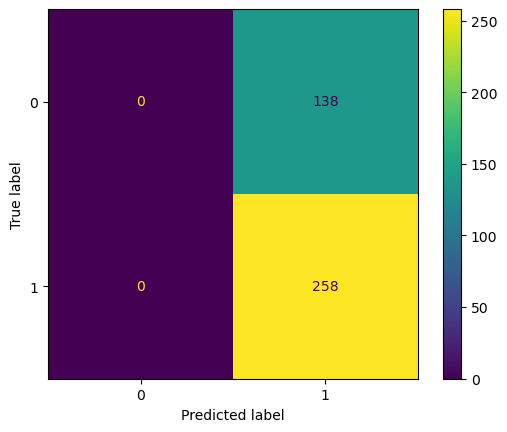

In [140]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Get predicted probabilities
y_pred_probs = My_ANN_Model.predict(testing_data)

# Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_probs > 0.25).astype("int32").flatten()
cm = confusion_matrix(test_labels, y_pred)

# Optional: display the matrix nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

In [128]:

My_ANN_Model.fit(
    training_data, train_labels,
    epochs=5,
    validation_data=(testing_data, test_labels),
    class_weight=class_weights_dict
)

Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5949 - auc: 0.5086 - loss: 0.7258 - precision: 0.6521 - recall: 0.8111 - val_accuracy: 0.3485 - val_auc: 0.5036 - val_loss: 0.7086 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4709 - auc: 0.5107 - loss: 0.6850 - precision: 0.5120 - recall: 0.4331 - val_accuracy: 0.6515 - val_auc: 0.5000 - val_loss: 0.6923 - val_precision: 0.6515 - val_recall: 1.0000
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6469 - auc: 0.5000 - loss: 0.6962 - precision: 0.6469 - recall: 1.0000 - val_accuracy: 0.6515 - val_auc: 0.5000 - val_loss: 0.6928 - val_precision: 0.6515 - val_recall: 1.0000
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6585 - auc: 0.5000 - loss: 0.6907 - precision: 0.6585 - recall: 1.0000 - val_accuracy: 0.6515 - val_auc: 0.5000 - val_loss: 0.6929 - val_precision: 0.6515 - val_recall: 1.0000
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━

In [129]:
np.unique(train_labels, return_counts=True)

(array([0, 1]), array([319, 601]))